# LSTM and GRU Model Training for Aircraft Engine RUL Prediction

This notebook trains deep learning models to predict Remaining Useful Life (RUL)
for aircraft engines using multivariate time-series sensor data.

The models use sequences generated from the NASA C-MAPSS turbofan dataset.

### Objectives

• Load prepared time-series sequences  
• Train LSTM and GRU deep learning models  
• Evaluate model performance  
• Compare model accuracy  
• Save trained models for deploymenttrained models

In [31]:
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout,  BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

## Load Prepared Sequence Data

The previous notebook generated time-series sequences for training.

Each sample has the structure:

X shape:
(number_of_samples, time_steps, number_of_features)

Target variable:
Remaining Useful Life (RUL)

In [18]:
BASE_DIR = Path(r"C:\Users\Kal\aircraft-engine-safety-risk-prediction")

DATA_DIR = BASE_DIR / "data" / "processed"

X_train = np.load(DATA_DIR / "X_fd004_train.npy")
y_train = np.load(DATA_DIR / "y_fd004_train.npy")

X_val = np.load(DATA_DIR / "X_fd004_val.npy")
y_val = np.load(DATA_DIR / "y_fd004_val.npy")

X_test = np.load(DATA_DIR / "X_fd004_test.npy")
y_test = np.load(DATA_DIR / "y_fd004_test.npy")

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)

Train: (43523, 30, 63) (43523,)
Validation: (10505, 30, 63) (10505,)


## Build LSTM Model (RUL Regression)

We use an LSTM network to learn temporal degradation patterns from sliding windows of sensor data.

Design choices:
- Two recurrent layers (64 → 32 units) to learn long- and medium-term patterns
- Dropout to reduce overfitting
- Dense layers to map learned representations to a single RUL prediction
- Loss: MSE (regression)
- Metric: MAE (interpretable in “cycles”)nance.

In [19]:
def build_lstm(input_shape, lr=1e-3):

    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        BatchNormalization(),
        Dropout(0.2),

        LSTM(32),
        BatchNormalization(),
        Dropout(0.2),

        Dense(16, activation="relu"),
        Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"]
    )

    return model

## Train LSTM Model

We train the model using early stopping to prevent overfitting.
Training stops automatically if validation performance stops improving.

In [20]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Build model
lstm_model = build_lstm(X_train.shape[1:], lr=1e-3)

# Early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Reduce learning rate if validation stops improving
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

# Train model
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/60


C:\Users\Kal\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


341/341 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 5691.7202 - mae: 64.8125 - val_loss: 2163.7180 - val_mae: 38.6009 - learning_rate: 0.0010
Epoch 2/60
341/341 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 1141.1182 - mae: 26.7573 - val_loss: 2655.0718 - val_mae: 42.6849 - learning_rate: 0.0010
Epoch 3/60
341/341 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 1021.0091 - mae: 24.6409 - val_loss: 955.6182 - val_mae: 23.6708 - learning_rate: 0.0010
Epoch 4/60
341/341 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 874.0174 - mae: 22.9017 - val_loss: 877.8045 - val_mae: 24.1406 - learning_rate: 0.0010
Epoch 5/60
341/341 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 863.0547 - mae: 22.9024 - val_loss: 939.2446 - val_mae: 21.0539 - learning_rate: 0.0010
Epoch 6/60
341/341 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 700.3008 - mae: 20.4223 - val_loss: 726.4205 - val_mae: 20.2606 - learning_rate: 0.0010
Epoch 7/60
341/341 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 689.1163 - mae: 20.1599 - val_loss: 1960.3651 - val

## Build GRU Model

Gated Recurrent Units (GRU) are a simplified version of LSTM.

They require fewer parameters and often train faster while still
capturing temporal dependencies in time-series data.

In [21]:
def build_gru(input_shape, lr=1e-3):
    """
    GRU model for Remaining Useful Life prediction.

    input_shape : (time_steps, num_features)
    lr          : learning rate for Adam optimizer
    """

    model = Sequential([
        GRU(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),

        GRU(32),
        Dropout(0.2),

        Dense(16, activation="relu"),
        Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"]
    )

    return model
    

## Train GRU Model

The GRU model is trained using the same training configuration
to allow a fair comparison with the LSTM model.

In [22]:
# Build GRU model
gru_model = build_gru(X_train.shape[1:], lr=1e-3)

# Train GRU model
history_gru = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/60
341/341 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 4652.8960 - mae: 58.8151 - val_loss: 1796.0881 - val_mae: 38.4816 - learning_rate: 0.0010
Epoch 2/60
339/341 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1777.5113 - mae: 37.5658
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
341/341 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 1618.5322 - mae: 35.3247 - val_loss: 822.6052 - val_mae: 24.1754 - learning_rate: 0.0010
Epoch 3/60
341/341 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 586.8604 - mae: 19.2342 - val_loss: 626.8596 - val_mae: 19.2266 - learning_rate: 5.0000e-04
Epoch 4/60
341/341 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 491.1686 - mae: 16.8058 - val_loss: 600.9037 - val_mae: 18.2878 - learning_rate: 5.0000e-04
Epoch 5/60
341/341 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 448.2788 - mae: 15.9831 - val_loss: 582.8718 - val_mae: 17.8600 - learning_rate: 5.0000e-04
Epoch 6/60
341/341 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 410.6727 - mae: 15.2897 - va

In [23]:


def select_last_window_per_engine(X, y, units, end_cycles):
    """
    Select the last sliding window for each engine.
    """

    idx_df = pd.DataFrame({
        "idx": np.arange(len(y)),
        "unit": units,
        "end_cycle": end_cycles
    })

    last_idx = (
        idx_df.sort_values(["unit", "end_cycle"])
              .groupby("unit")
              .tail(1)["idx"]
              .values
    )

    return X[last_idx], y[last_idx], units[last_idx], end_cycles[last_idx]

## Create Engine-Level Test Set (Last Window per Engine)

Airline maintenance decisions are made using the **latest available
sensor data for each engine**.

Therefore we select the **last sliding window per engine** to perform
engine-level evaluation.

In [24]:
# Load engine-level evaluation arrays
u_test_last = np.load(DATA_DIR / "u_fd004_test_last.npy")
c_test_last = np.load(DATA_DIR / "c_fd004_test_last.npy")

# Last window per engine already saved
X_test_last = np.load(DATA_DIR / "X_fd004_test_last.npy")
y_test_last = np.load(DATA_DIR / "y_fd004_test_last.npy")

print("Engine-level dataset shape:", X_test_last.shape)
print("Number of engines:", len(np.unique(u_test_last)))

Engine-level dataset shape: (237, 30, 63)
Number of engines: 237


## Model Evaluation

We evaluate both models in two ways:

1. **Window-level evaluation**  
   Measures performance across all sliding windows.

2. **Engine-level evaluation (airline-style)**  
   Uses only the **last window per engine**, which better reflects how
   maintenance and safety decisions are made in practice.ul Life.

In [25]:

# 1) Window-level evaluation
# =========================
y_pred_lstm_win = lstm_model.predict(X_test).flatten()
y_pred_gru_win = gru_model.predict(X_test).flatten()

mae_lstm_win = mean_absolute_error(y_test, y_pred_lstm_win)
rmse_lstm_win = np.sqrt(mean_squared_error(y_test, y_pred_lstm_win))

mae_gru_win = mean_absolute_error(y_test, y_pred_gru_win)
rmse_gru_win = np.sqrt(mean_squared_error(y_test, y_pred_gru_win))

print("Window-Level Evaluation")
print("-----------------------")
print("LSTM MAE :", round(mae_lstm_win, 3))
print("LSTM RMSE:", round(rmse_lstm_win, 3))
print("GRU  MAE :", round(mae_gru_win, 3))
print("GRU  RMSE:", round(rmse_gru_win, 3))

# ======================================
# 2) Engine-level evaluation (AA-style)
# ======================================
y_pred_lstm_eng = lstm_model.predict(X_test_last).flatten()
y_pred_gru_eng = gru_model.predict(X_test_last).flatten()

mae_lstm_eng = mean_absolute_error(y_test_last, y_pred_lstm_eng)
rmse_lstm_eng = np.sqrt(mean_squared_error(y_test_last, y_pred_lstm_eng))

mae_gru_eng = mean_absolute_error(y_test_last, y_pred_gru_eng)
rmse_gru_eng = np.sqrt(mean_squared_error(y_test_last, y_pred_gru_eng))

print("\nEngine-Level Evaluation (Last Window per Engine)")
print("------------------------------------------------")
print("LSTM MAE :", round(mae_lstm_eng, 3))
print("LSTM RMSE:", round(rmse_lstm_eng, 3))
print("GRU  MAE :", round(mae_gru_eng, 3))
print("GRU  RMSE:", round(rmse_gru_eng, 3))

1066/1066 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
1066/1066 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
Window-Level Evaluation
-----------------------
LSTM MAE : 22.641
LSTM RMSE: 28.144
GRU  MAE : 18.557
GRU  RMSE: 24.42
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

Engine-Level Evaluation (Last Window per Engine)
------------------------------------------------
LSTM MAE : 27.576
LSTM RMSE: 35.234
GRU  MAE : 24.22
GRU  RMSE: 32.348


## Prediction Visualization (Engine-Level)

We visualize predicted Remaining Useful Life (RUL) against the true RUL
for the **latest window of each engine**.

This reflects the operational scenario where airlines make decisions
based on the most recent sensor data.ce.

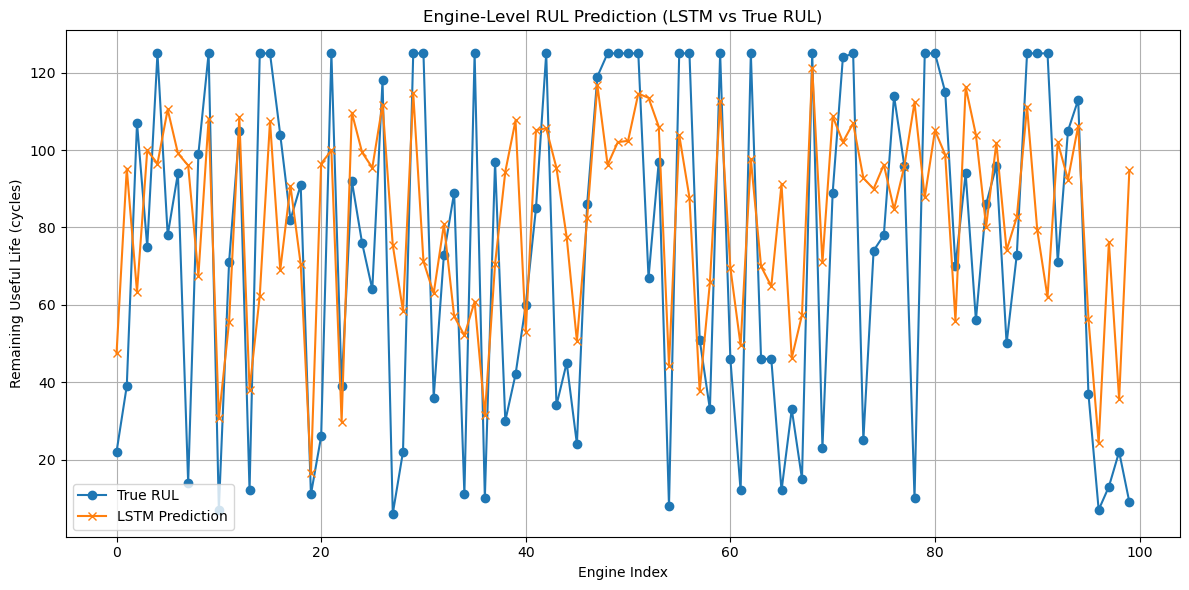

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# True RUL
plt.plot(y_test_last[:100], marker="o", label="True RUL")

# Predicted RUL
plt.plot(y_pred_lstm_eng[:100], marker="x", label="LSTM Prediction")

plt.xlabel("Engine Index")
plt.ylabel("Remaining Useful Life (cycles)")
plt.title("Engine-Level RUL Prediction (LSTM vs True RUL)")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

compare LSTM vs GRU in one chart.

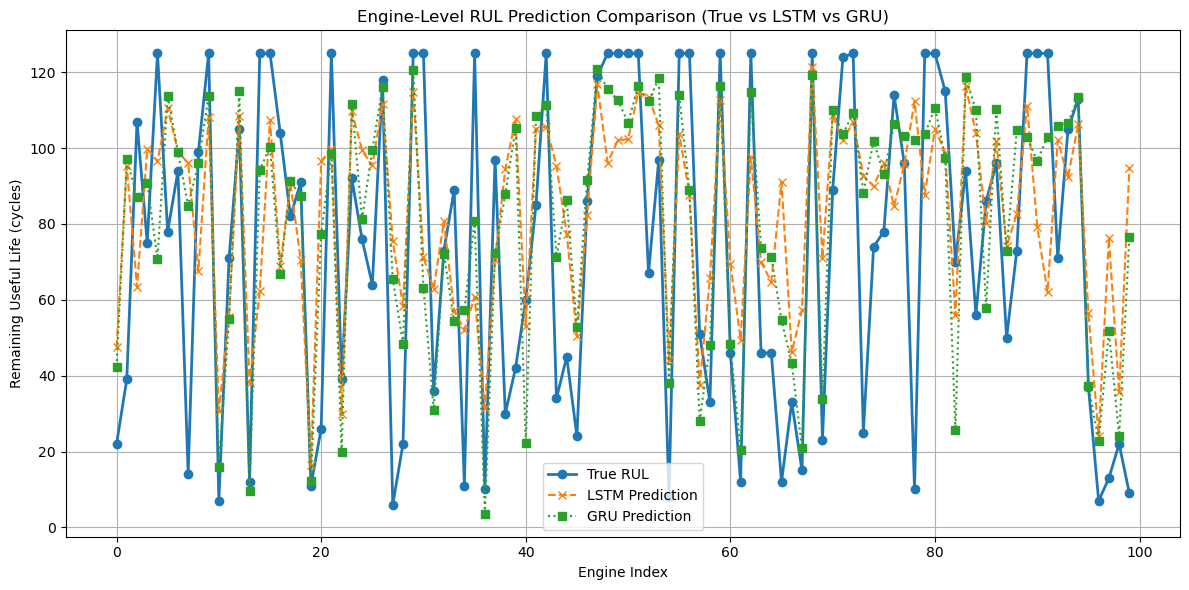

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test_last[:100], marker="o", linewidth=2, label="True RUL")
plt.plot(y_pred_lstm_eng[:100], marker="x", linestyle="--", label="LSTM Prediction")
plt.plot(y_pred_gru_eng[:100], marker="s", linestyle=":", label="GRU Prediction")

plt.xlabel("Engine Index")
plt.ylabel("Remaining Useful Life (cycles)")
plt.title("Engine-Level RUL Prediction Comparison (True vs LSTM vs GRU)")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

## Model Performance Comparison

To clearly compare the predictive performance of the trained models,
we summarize the evaluation metrics in a single table.

The comparison includes both:

- **Window-level evaluation** – measures prediction accuracy across all sliding windows.
- **Engine-level evaluation (AA-style)** – evaluates predictions using the latest
  window per engine, which better reflects real-world maintenance decision scenarios.

The metrics used are:

- **MAE (Mean Absolute Error)** – average absolute prediction error.
- **RMSE (Root Mean Squared Error)** – penalizes larger prediction errors more strongly.

This comparison helps determine which model performs better for
Remaining Useful Life (RUL) prediction in aircraft engines.

In [32]:
comparison = pd.DataFrame({
    "Model": ["LSTM", "GRU"],
    "MAE_window": [mae_lstm_win, mae_gru_win],
    "RMSE_window": [rmse_lstm_win, rmse_gru_win],
    "MAE_engine": [mae_lstm_eng, mae_gru_eng],
    "RMSE_engine": [rmse_lstm_eng, rmse_gru_eng]
})

comparison

,Model,MAE_window,RMSE_window,MAE_engine,RMSE_engine
0,LSTM,22.640722,28.144341,27.576410,35.233841
1,GRU,18.556637,24.419958,24.220118,32.348248


## Save Trained Models

The trained LSTM and GRU models are saved locally for later use in:

• Risk scoring  
• Fleet ranking  
• Maintenance decision support  

Model artifacts are stored in the `models/` directory and excluded from
GitHub version control via `.gitignore`.tignore`.coring

In [33]:
from pathlib import Path

MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

lstm_path = MODEL_DIR / "lstm_rul_model.h5"
gru_path = MODEL_DIR / "gru_rul_model.h5"

lstm_model.save(lstm_path)
gru_model.save(gru_path)

print("Models saved successfully:")
print(lstm_path)
print(gru_path)

Models saved successfully:
C:\Users\Kal\aircraft-engine-safety-risk-prediction\models\lstm_rul_model.h5
C:\Users\Kal\aircraft-engine-safety-risk-prediction\models\gru_rul_model.h5


# Summary

This notebook trained deep learning models for aircraft engine
Remaining Useful Life (RUL) prediction using time-series sensor data.

Completed tasks:

✔ Trained LSTM model  
✔ Trained GRU model  
✔ Evaluated window-level prediction performance  
✔ Evaluated engine-level performance using the latest window per engine  
✔ Compared LSTM and GRU model accuracy  
✔ Visualized engine-level prediction results  
✔ Saved trained models for downstream risk scoring and decision support  

## Next Step

The next notebook will convert RUL predictions into operational safety outputs:

• Risk scoring  
• Risk level classification  
• Early warning alerts  
• Fleet-level engine risk ranking  

This will move the project from model prediction to aviation safety
decision support.